# Preparing a nested simulation with CDR iii: Parent simulation re-run with upscaled CDR tracers

In the previous two steps of this tutorial, we ran the parent and child of a two-domain nested regional ocean simulation in ROMS. In the previous step, we ran the child domain, including an alkalinity perturbation off the northwest coast of Iceland, before looking at the impact on dissolved inorganic carbon. The additional alkalinity quickly reached the bounaries of the simulation, and so in order to study the evolution of the perturbation in the wider ocean, we again need to run the parent, upscaling the boundary CDR tracers.

## Requirements:
The requirements are the same as the previous step in the tutorial, with the addition that the previous step must have been successfully completed and its outputs available.

We no longer need to generate any forcing, as we have already prepared everything for this domain. All that remains is to translate the boundary CDR tracers into forcing to be read:

In [1]:
%matplotlib inline

In [2]:
#Make sure we are in the correct directory for the rest of this notebook

import os
os.chdir(f"{os.environ.get("ROMS_ROOT")}/Examples/Iceland/Iceland_parent_with_upscaling")

In [3]:
from pathlib import Path

import xarray as xr
import datetime as dt
import roms_tools as rt
import matplotlib.pyplot as plt

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## Translating child-boundary CDR tracer fluxes -> parent-domain CDR forcing

We will now consider the `_uscl` files produced by the previous run. Note that it is necessary to have already performed the `ncjoin` post-processing step on these files (as we did in the previous step). ROMS includes a tool to convert these joined `_uscl` files into CDR forcing files to be read by the parent (`uscl_to_cdr`):

In [4]:
%%bash
uscl_to_cdr $ROMS_ROOT/Examples/Iceland/Iceland_child/output/iceland_child_uscl.??????????????.nc -o \
input_data/cdr_release_profiles_from_child.nc

Opening 29 `_uscl` files...
Found 776 boundary tracer profiles to convert to CDR forcing profiles
Populating `cdr_lat`...
Populating `cdr_lon`...
Populating `cdr_trcflx_profile` for tracer ALK...
Populating `cdr_trcflx_profile` for tracer DIC...
Populating `cdr_layer_thickness`...
Saving output to input_data/cdr_release_profiles_from_child.nc
Done.


We must update the `cdr_frc.opt` file from the original parent simulation to include this information:


| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `cdr_frc.opt` | `cdr_source` | Tells ROMS we will be applying CDR forcing | `.true.` |
|               | `cdr_file` | Path to the netCDF file we created with `uscl_to_cdr` | `input_data/cdr_release_profiles_from_child.nc` |
|               | `forcing_3d`* | Tells ROMS that we are providing forcing with a fully specified 3D spatial distribution | `.false.` |
|               | `forcing_depth_profiles`* | Tells ROMS that we are providing forcing as a sequence of 2D depth profiles | `.true.` |
|               | `forcing_parameterized`* | Tells ROMS that we are providing forcing as a parameterized spatial distribution | `.false.` |
|               | `cdr_volume`| Tells ROMS that the CDR release will be a [volume flux](https://roms-tools.readthedocs.io/en/latest/cdr_forcing.html#Creating-a-Release), rather than a tracer flux | `.false.` |
|               | `nz_chd`| The number of layers in the forcing file, i.e. the number of vertical levels in our child domain | `20` |

Note that, unlike the child simulation in which the CDR release originally took place, we now use `forcing_depth_profiles` rather than `forcing_parameterized`. This is because we are prescribing CDR forcing from flux profiles recorded at each boundary column in the child simulation, rather than as a parameterized Guassian perturbation, as was the case for the initial release.


## Other inputs
These are the same as the `Iceland_parent` simulation we ran before, so we can create symbolic links to the existing files. We also need the restart file from the `Iceland_parent/output` directory:

In [5]:
%%bash
cd input_data
ln -s ../../Iceland_parent/input_data/* .
ln -s ../../Iceland_parent/output/iceland_parent_rst.* .

## Configuring output
As we are evolving a CDR intervention, we can use the `cdr_output` module as on the previous page. The settings are the same. Similarly, we no longer require other forms of output, so turn these off:

| File          | Variable      | Description   |  Value        | 
| ------------- | ------------- | ------------- | ------------- |
| `ocean_vars.opt` | `wrt_file_rst` | Tells ROMS whether to  write restart files | `.false.` |
|                  | `wrt_file_his` | Tells ROMS whether to  write ocean "history" files (snapshots of the model state) | `.false.` |
|                  | `wrt_file_avg` | Tells ROMS whether to  write ocean average files (time averages of the model state) | `.false.` |
|    `bgc.opt`     | `wrt_his` | Tells ROMS whether to  write BGC "history" files (snapshots of BGC tracers) | `.false.` |
|                  | `wrt_avg` | Tells ROMS whether to  write BGC average files (time averages of BGC tracers) | `.false.` |
|                  | `wrt_his_dia` | Tells ROMS whether to  write BGC diagnostic "history" files (snapshots of BGC diagnostics) |`.false.`|
|                  | `wrt_avg_dia` | Tells ROMS whether to  write BGC average files (time averages of BGC diagnostics) | `.false.` |
|`cdr_output.opt`| `do_cdr` | Tells ROMS whether to write mCDR-specific outputs | `.true.` |
|                  | `do_avg` | Tells ROMS whether to write instantaneous or time-averaged outputs | `.true.` |
|                  | `output_period` | requency of file creation / averaging period (if `.do_avg.`)(s) | `86400` (daily) |
|                  | `monthly_averages` | If `true`, ignores above frequency and averages over each _calendar_ month | `.false.` |
|                  | `nprf` | Number of records in each output file before beginning a new file | `28` |

## Compiling and running the model

In [ ]:
%%bash
make compile_clean
make

_(Cell output hidden due to length)_

In [ ]:
%%bash
mpirun -n 9 ./roms roms.in

_(Cell output hidden due to length)_

## Post-processing and output visualization

In [ ]:
%%bash
cd output
# We want to loop over the filename stems, so we'll use the `.0.nc` files as a template
for F in iceland_parent_cstar.??????????????.0.nc;do
    filename_stem=${F/.0.nc}  

    # wildcard to join all subdomains with this stem
    ncjoin ${filename_stem}.?.nc
done

_(Cell output hidden due to length)_

In [9]:
ls output/iceland_parent_cstar.*.nc

output/iceland_parent_cstar.20120202000000.0.nc
output/iceland_parent_cstar.20120202000000.1.nc
output/iceland_parent_cstar.20120202000000.2.nc
output/iceland_parent_cstar.20120202000000.3.nc
output/iceland_parent_cstar.20120202000000.4.nc
output/iceland_parent_cstar.20120202000000.5.nc
output/iceland_parent_cstar.20120202000000.6.nc
output/iceland_parent_cstar.20120202000000.7.nc
output/iceland_parent_cstar.20120202000000.8.nc
output/iceland_parent_cstar.20120202000000.nc


/var/folders/1s/xjsjyqrj2rdft8014664qczc0000gn/T/ipykernel_68869/3087560374.py:6: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data_ds=xr.open_dataset("output/iceland_parent_cstar.20120202000000.nc")
/var/folders/1s/xjsjyqrj2rdft8014664qczc0000gn/T/ipykernel_68869/3087560374.py:7: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the 

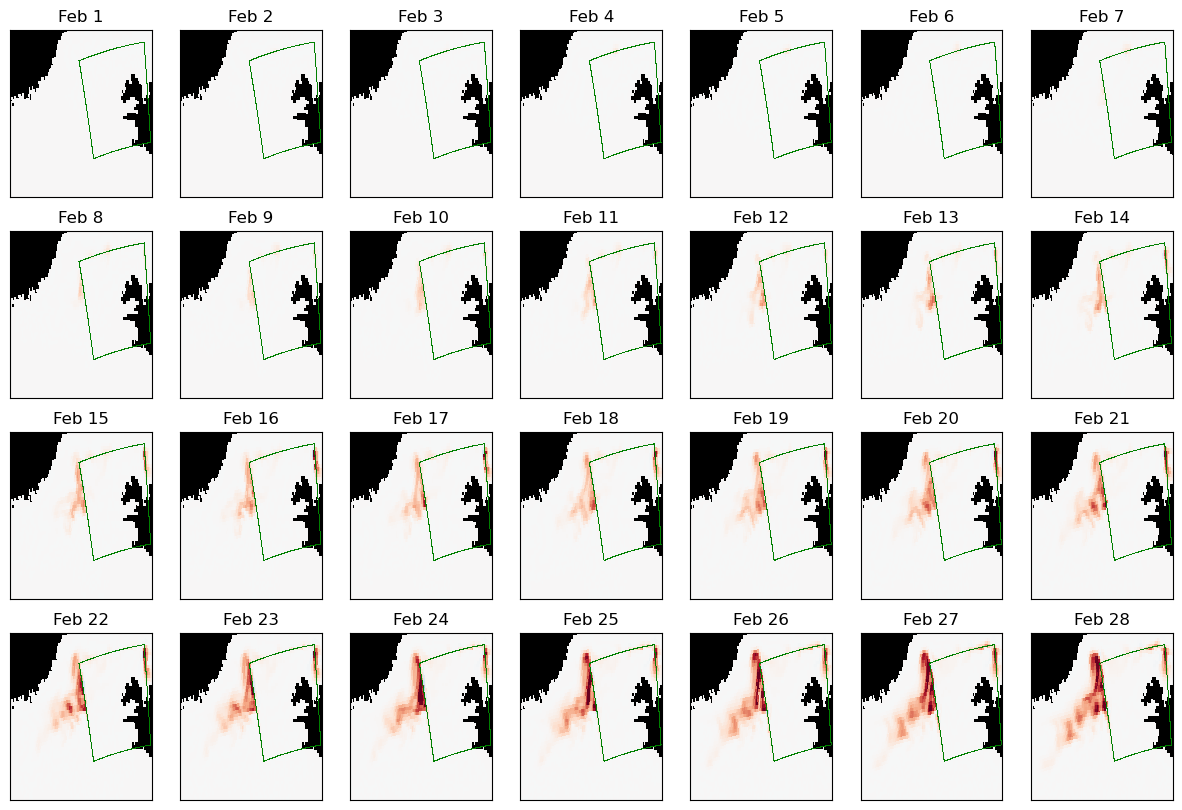

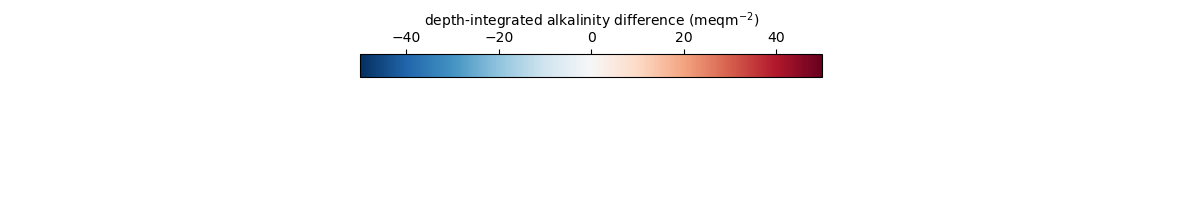

In [10]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

grid_ds=xr.open_dataset("input_data/iceland_parent_grid.nc")
data_ds=xr.open_dataset("output/iceland_parent_cstar.20120202000000.nc")
cdr_ds =xr.open_dataset("input_data/cdr_release_profiles_from_child.nc")
dalk_feb = (data_ds["hALK"]-data_ds["hALK_ALT_CO2"]).sum("s_rho")

# Set up figure
fig,ax=plt.subplots(4,7)
fig.set_size_inches(15,10)

# Diverging colormap with black on land
cmap = plt.get_cmap("RdBu_r")
cmap.set_bad("k")

# Add panels for different days of output
for i in range(28):
    a = ax.reshape(-1)[i]
    field=dalk_feb.isel(time=i).where(grid_ds.mask_rho)
    p=a.pcolormesh(grid_ds.lon_rho, grid_ds.lat_rho, field,vmin=-50,vmax=50,cmap=cmap)
    a.set_xlim(320,340)
    a.set_ylim(62,68)
    # Plot the CDR release locations i.e. child domain boundaries 
    a.plot(cdr_ds.cdr_lon,cdr_ds.cdr_lat,'g,')
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlabel("")
    a.set_ylabel("")
    a.set_title(f"Feb {i+1}")

# Add a shared colorbar
fig2,ax2=plt.subplots()
cb=fig2.colorbar(p,ax=ax2,orientation="horizontal",location="top",label=r"depth-integrated alkalinity difference (meqm$^{-2}$)")
fig2.set_size_inches(15,2)
ax2.set_axis_off()




/var/folders/1s/xjsjyqrj2rdft8014664qczc0000gn/T/ipykernel_68869/2333302081.py:6: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  data_ds=xr.open_dataset("output/iceland_parent_cstar.20120202000000.nc")
/var/folders/1s/xjsjyqrj2rdft8014664qczc0000gn/T/ipykernel_68869/2333302081.py:7: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the 

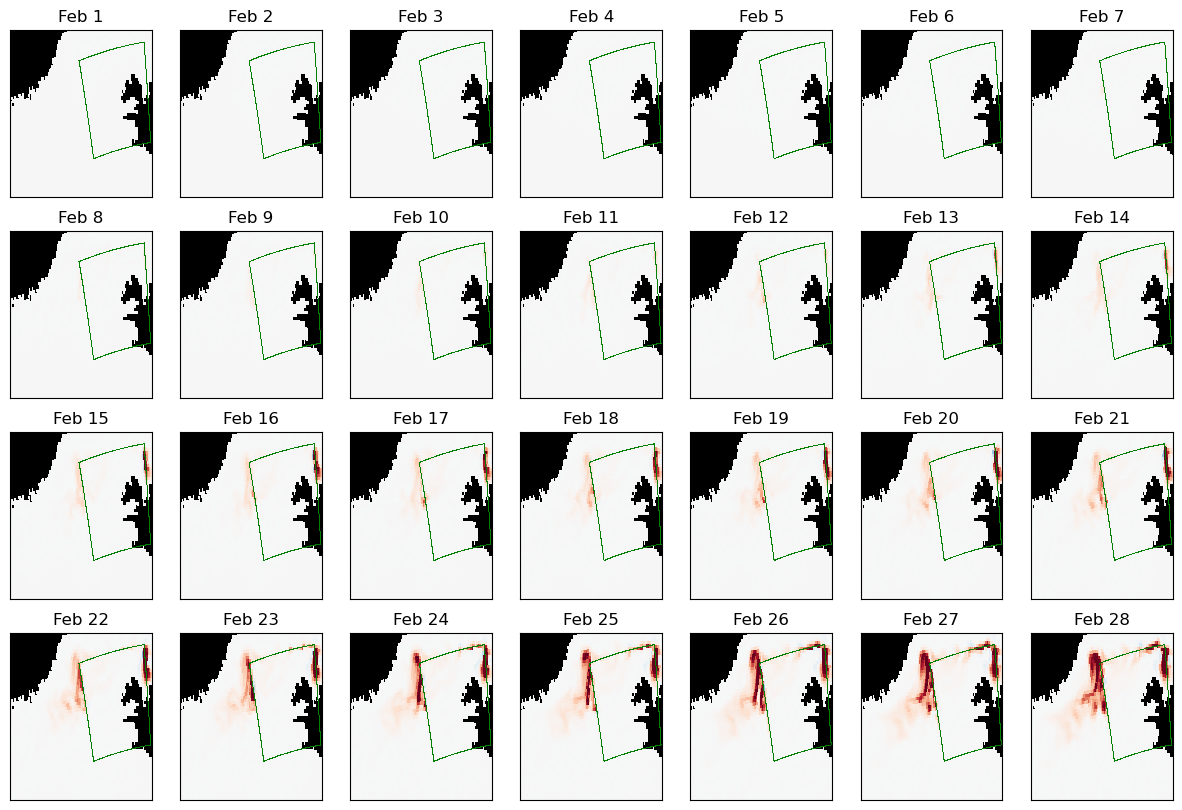

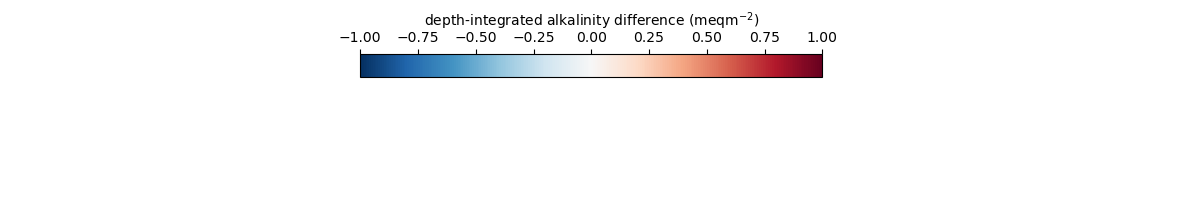

In [13]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

grid_ds=xr.open_dataset("input_data/iceland_parent_grid.nc")
data_ds=xr.open_dataset("output/iceland_parent_cstar.20120202000000.nc")
cdr_ds =xr.open_dataset("input_data/cdr_release_profiles_from_child.nc")
dalk_feb = (data_ds["hDIC"]-data_ds["hDIC_ALT_CO2"]).sum("s_rho")

# Set up figure
fig,ax=plt.subplots(4,7)
fig.set_size_inches(15,10)

# Diverging colormap with black on land
cmap = plt.get_cmap("RdBu_r")
cmap.set_bad("k")

# Add panels for different days of output
for i in range(28):
    a = ax.reshape(-1)[i]
    field=dalk_feb.isel(time=i).where(grid_ds.mask_rho)
    p=a.pcolormesh(grid_ds.lon_rho, grid_ds.lat_rho, field,vmin=-1,vmax=1,cmap=cmap)
    a.set_xlim(320,340)
    a.set_ylim(62,68)
    # Plot the CDR release locations i.e. child domain boundaries 
    a.plot(cdr_ds.cdr_lon,cdr_ds.cdr_lat,'g,')
    a.set_xticks([])
    a.set_yticks([])
    a.set_xlabel("")
    a.set_ylabel("")
    a.set_title(f"Feb {i+1}")

# Add a shared colorbar
fig2,ax2=plt.subplots()
cb=fig2.colorbar(p,ax=ax2,orientation="horizontal",location="top",label=r"depth-integrated alkalinity difference (meqm$^{-2}$)")
fig2.set_size_inches(15,2)
ax2.set_axis_off()




## Summary
Over the course of this tutorial, we have run a nested simulation of an ocean alkalinity enhancement off the coast of Iceland. We began by setting up and running a simulation of the wider region (forced with reanalysis data) for two months. In the second step, we used outputs from this parent simulation to generate the boundary forcing and initial conditions for a higher-resolution, one-month child simulation of the OAE release region. This child simulation also featured the alkalinity perturbation. As the anomalous alkalinity quickly reached the boundary of the child domain, we utilized ROMS' upscaling functionality to track any CDR tracer fluxes out of the domain. Finally, on this page we have re-run the parent configuration, including those fluxes, to track their propagation into the broader region.